
# Cross Validation in Machine Learning

This notebook explains:
- What is Cross Validation
- K-Fold Cross Validation
- Stratified K-Fold (Classification)
- Model Comparison using Cross Validation

---


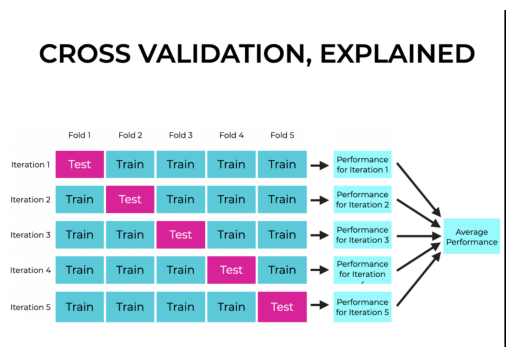

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("image/cross_validation.png")
plt.imshow(img)
plt.axis("off")
plt.show()

# KFold - regression

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

from sklearn.datasets import load_iris
iris=load_iris()

X=iris.data
y=iris.target

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5)

print("Regression - Fold Scores:", scores)
print("Mean Score:", scores.mean())
print("Standard Deviation:", scores.std())


Regression - Fold Scores: [0.         0.85124923 0.         0.76155439 0.        ]
Mean Score: 0.32256072489000853
Standard Deviation: 0.39607151910352606



## Stratified K-Fold (Classification)

For classification problems, sklearn uses StratifiedKFold by default.
This maintains class balance in each fold.


In [4]:
from sklearn.svm import SVC

from sklearn.datasets import load_iris
iris=load_iris()

X=iris.data
y=iris.target

model = SVC()

scores = cross_val_score(model, X, y, cv=5)

print("Classification - Accuracy per Fold:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())


Classification - Accuracy per Fold: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Mean Accuracy: 0.9666666666666666
Standard Deviation: 0.02108185106778919



## Model Comparison Using Cross Validation

We compare multiple models and choose the best one based on:
- Higher mean score
- Lower standard deviation


In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVC": SVC()
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}")
    print("Mean:", scores.mean())
    print("Std:", scores.std())
    print("-----------")


LogisticRegression
Mean: 0.9733333333333334
Std: 0.02494438257849294
-----------
RandomForest
Mean: 0.9666666666666668
Std: 0.02108185106778919
-----------
SVC
Mean: 0.9666666666666666
Std: 0.02108185106778919
-----------
